Museum of Modern Art Collection
-- https://www.kaggle.com/datasets/momanyc/museum-collection/data

Análise e classificação de obras de arte do MoMA usando visão computacional

In [1]:
%pip install pandas matplotlib numpy

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 642.4 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------------- --------- 92.2/121.0 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 1.8 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
    --------------------------------------- 0.2/10.0 MB 7.6 MB/s eta 0:00:02
   - -------------------------------------- 0.3/10.0 MB 4.2 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/10.0 MB 5.5 MB/s eta 0:00:02
   --- ------------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


02 - Importação das bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
df = pd.read_csv("data/moma/artworks.csv")
df.head()

,Artwork ID,Title,Artist ID,Name,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,...,Classification,Object Number,Diameter (cm),Circumference (cm),Height (cm),Length (cm),Width (cm),Depth (cm),Weight (kg),Duration (s)
0,2,"Ferdinandsbrücke Project, Vienna, Austria, Ele...",6210,Otto Wagner,1896,Ink and cut-and-pasted painted pages on paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",1996-04-09,Fractional and promised gift of Jo Carole and ...,Y,...,Architecture,885.1996,NaN,NaN,48.6000,NaN,168.9000,NaN,NaN,NaN
1,3,"City of Music, National Superior Conservatory ...",7470,Christian de Portzamparc,1987,Paint and colored pencil on print,"16 x 11 3/4"" (40.6 x 29.8 cm)",1995-01-17,Gift of the architect in honor of Lily Auchinc...,Y,...,Architecture,1.1995,NaN,NaN,40.6401,NaN,29.8451,NaN,NaN,NaN
2,4,"Villa near Vienna Project, Outside Vienna, Aus...",7605,Emil Hoppe,1903,"Graphite, pen, color pencil, ink, and gouache ...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,Architecture,1.1997,NaN,NaN,34.3000,NaN,31.8000,NaN,NaN,NaN
3,5,"The Manhattan Transcripts Project, New York, N...",7056,Bernard Tschumi,1980,Photographic reproduction with colored synthet...,"20 x 20"" (50.8 x 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,...,Architecture,2.1995,NaN,NaN,50.8000,NaN,50.8000,NaN,NaN,NaN
4,6,"Villa, project, outside Vienna, Austria, Exter...",7605,Emil Hoppe,1903,"Graphite, color pencil, ink, and gouache on tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,Architecture,2.1997,NaN,NaN,38.4000,NaN,19.1000,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130262 entries, 0 to 130261
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Artwork ID          130262 non-null  int64  
 1   Title               130200 non-null  str    
 2   Artist ID           128802 non-null  str    
 3   Name                128802 non-null  str    
 4   Date                127950 non-null  str    
 5   Medium              118343 non-null  str    
 6   Dimensions          118799 non-null  str    
 7   Acquisition Date    124799 non-null  str    
 8   Credit              127192 non-null  str    
 9   Catalogue           130262 non-null  str    
 10  Department          130262 non-null  str    
 11  Classification      130262 non-null  str    
 12  Object Number       130262 non-null  str    
 13  Diameter (cm)       1399 non-null    float64
 14  Circumference (cm)  10 non-null      float64
 15  Height (cm)         111893 non-null  float64


In [5]:
df.describe(include="all")

,Artwork ID,Title,Artist ID,Name,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,...,Classification,Object Number,Diameter (cm),Circumference (cm),Height (cm),Length (cm),Width (cm),Depth (cm),Weight (kg),Duration (s)
count,130262.000000,130200,128802,128802,127950,118343,118799,124799,127192,130262,...,130262,130262,1399.000000,10.000000,111893.000000,736.000000,111003.000000,11443.000000,298.000000,3.084000e+03
unique,NaN,94881,13575,13530,9373,19348,78464,1876,7030,2,...,28,130262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Untitled,229,Eugène Atget,1971,Gelatin silver print,"Approx. 8 11/16 x 7 1/16"" (22 x 18 cm)",1964-10-06,The Louis E. Stern Collection,Y,...,Print,885.1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7180,5050,5050,1748,14103,923,11220,10927,71333,...,30807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,82501.371636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,23.248939,44.868020,37.712992,89.117417,38.176838,18.291359,1248.278691,7.830060e+03
std,58124.331702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,45.460079,28.631604,48.151347,329.717487,67.250118,57.703925,11856.456824,1.185046e+05
min,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.635000,9.900000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000e+00
25%,34171.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.900000,23.500000,18.100000,17.031875,17.800000,0.000000,5.443200,2.100000e+02
50%,69541.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.700000,36.000000,27.940056,26.700000,25.400100,0.700000,19.051100,7.200000e+02
75%,128955.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,24.782500,71.125000,44.450100,79.100000,44.800000,13.335013,65.318000,3.613250e+03


3. Fazer uma análise exploratória

Descobrir quais artistas possuem mais obras

In [8]:
df["Name"].value_counts().head(20)

Name
Eugène Atget                5050
Louise Bourgeois            3318
Ludwig Mies van der Rohe    2566
Unknown photographer        1575
Jean Dubuffet               1435
Lee Friedlander             1317
Pablo Picasso               1310
Marc Chagall                1162
Henri Matisse               1063
Pierre Bonnard               894
Lilly Reich                  823
Frank Lloyd Wright           799
George Maciunas              762
August Sander                749
Unknown Artist               680
Georges Rouault              632
Émile Bernard                631
Ben Kinmont                  597
Aristide Maillol             579
André Derain                 573
Name: count, dtype: int64

Quais técnicas aparecem mais!

In [10]:
df["Medium"].value_counts().head(20)

Medium
Gelatin silver print                       14103
Lithograph                                  7034
Albumen silver print                        4845
Lithograph, printed in color                1833
Pencil on paper                             1725
Etching                                     1710
Lithograph, printed in black                1523
Chromogenic color print                     1488
Letterpress                                 1420
Ink on paper                                1388
Pencil on tracing paper                     1233
Oil on canvas                               1064
Drypoint                                    1040
Video (color, sound)                         983
Offset lithograph                            978
Woodcut                                      962
Screenprint                                  899
Gelatin silver printing-out-paper print      877
Etching, printed in black                    696
35mm film                                    696
Name: count, 

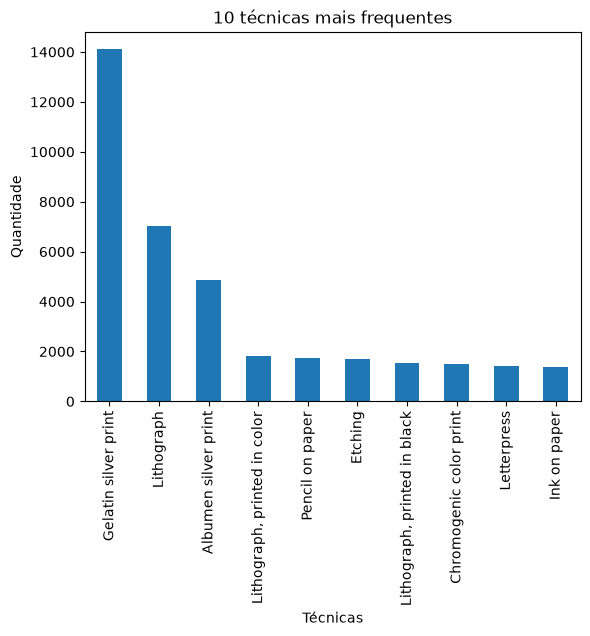

In [11]:
df["Medium"].value_counts().head(10).plot(kind="bar")

plt.title("10 técnicas mais frequentes")
plt.xlabel("Técnicas")
plt.ylabel("Quantidade")
plt.show()